## Cálculo de los días tipo

### K-Means clustering

#### Load the data

In [2]:
import pandas as pd

data_types = {'origen': 'string',
			  'destino': 'string', 
			  'distancia': 'string',
			  'weekday_flag': 'int64',
			  'viajes': 'float',
			  'viajes_km': 'float'
}

criteria = list(data_types.keys())
parse_dates = ['date_str']

data = pd.read_csv("D:/Documents/Proyectos/Data/MITMA/3-Results/Salamanca_MITMA_2023.csv", dtype=data_types, parse_dates=parse_dates)
data = data[criteria + parse_dates]

print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15123350 entries, 0 to 15123349
Data columns (total 7 columns):
 #   Column        Dtype         
---  ------        -----         
 0   origen        string        
 1   destino       string        
 2   distancia     string        
 3   weekday_flag  int64         
 4   viajes        float64       
 5   viajes_km     float64       
 6   date_str      datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), string(3)
memory usage: 807.7 MB
None


#### Calculate the optimal number of clusters

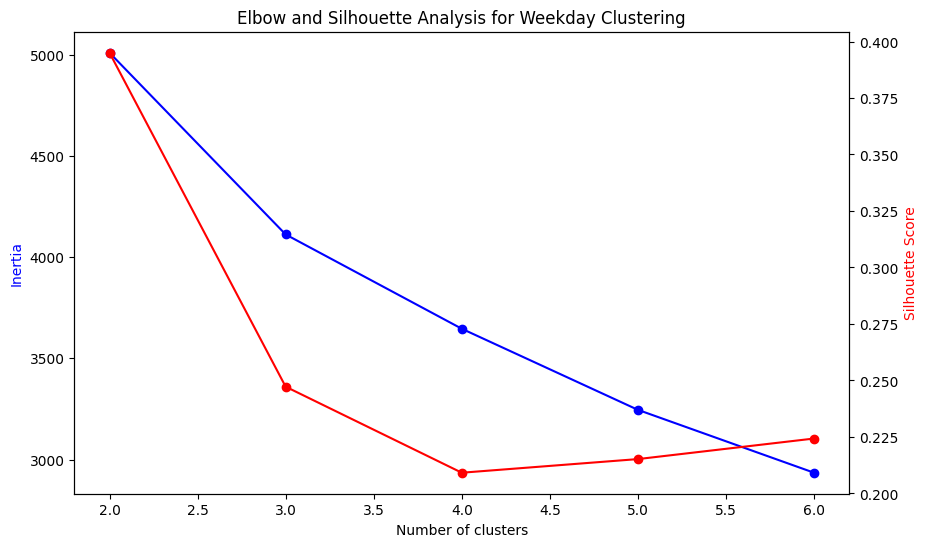

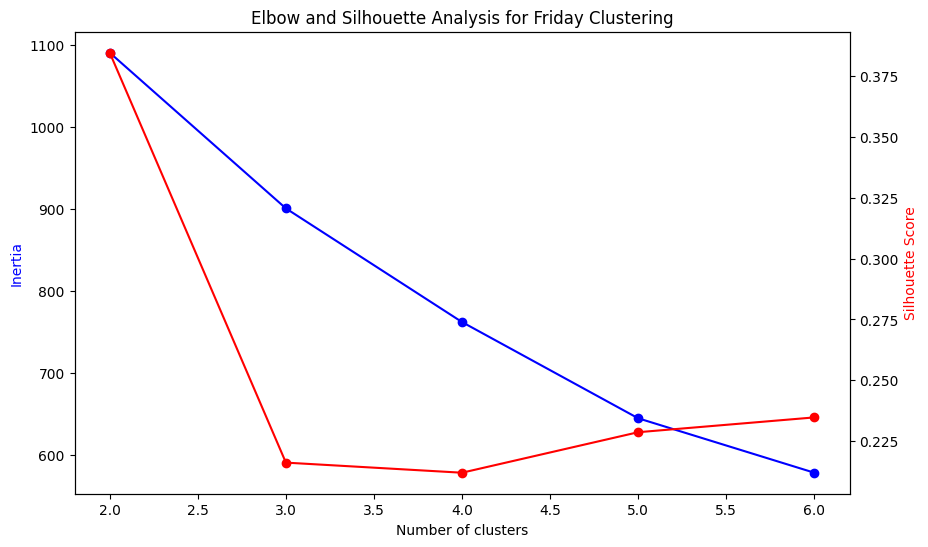

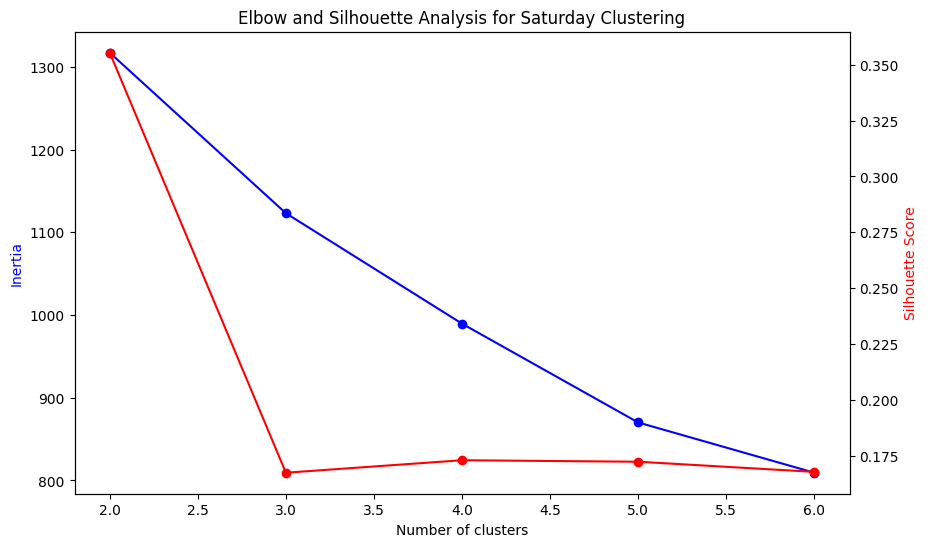

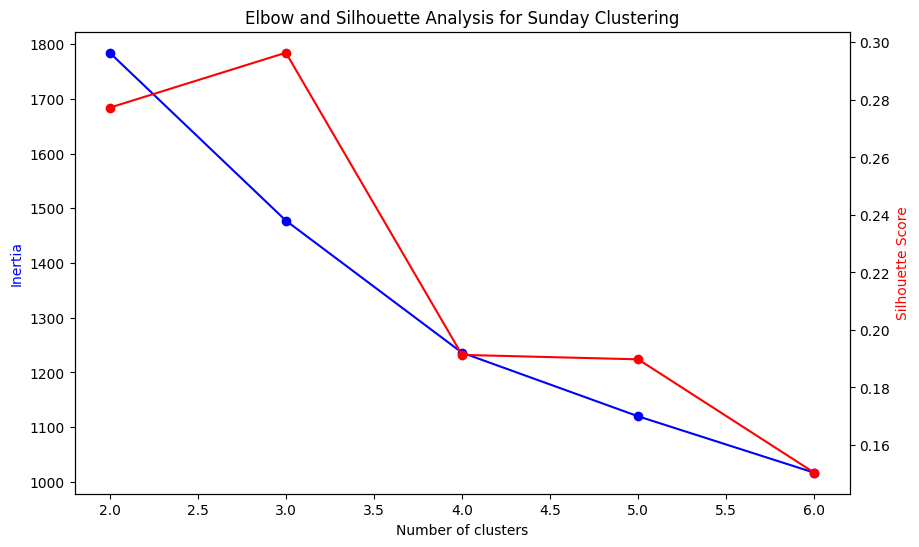

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Step 0 data pre-processing
# Create a concatenate column
data['OD_pair'] = data['origen'] + '-' + data['destino']

# Perform a groupby to collapse the data after ignoring socioeconomic features: income, gender, age
data = data.groupby(['origen', 'destino', 'OD_pair', 'weekday_flag', 'date_str']).agg(
	viajes=('viajes', 'sum'),
	viajes_km=('viajes_km', 'sum')
).reset_index()

# Exclude national bank holidays
bank_holidays = pd.to_datetime([ 
	'02 January 2023',
	'06 January 2023',
	'06 April 2023',
	'07 April 2023',
	'24 April 2023',
	'01 May 2023',
	'12 June 2023',
	'15 August 2023',
	'08 September 2023',
	'12 October 2023',
	'01 November 2023',
	'06 December 2023',
	'08 December 2023',
	'25 December 2023'
])

bank_holiday_eves = bank_holidays - pd.Timedelta(days=1)

# 2. Convert 'date_str' to numerical representation (e.g., days since min date)
data['date_num'] = (data['date_str'] - data['date_str'].min()).dt.days

# Add a flag for bank holidays from the custom list above
data['bh_flag'] = data['date_str'].isin(bank_holidays).astype(int)

# Exclude the diagonal
data = data.loc[data['origen'] != data['destino']]
# print(f"After collapsing the data and excluding the diagonal, the number of rows is: {len(data)}")

# Areas in scope 
# in_scope = ['...', '...', '...']


data_weekday = data[data['weekday_flag'] == 1]
data_weekday = data_weekday[data_weekday['bh_flag'] == 0]
# data_weekday = data_weekday[data_weekday['origen'].isin(in_scope)]
# data_weekday = data_weekday[data_weekday['destino'].isin(in_scope)]

data_weekend = data[data['weekday_flag'] == 0]
data_bh = data[data['bh_flag'] == 1]
data_non_working = pd.concat([data_weekend, data_bh])
# data_non_working = data_non_working[data_non_working['origen'].isin(in_scope)]
# data_non_working = data_non_working[data_non_working['destino'].isin(in_scope)]

# # Exclude small relationships: less than 4000 trips per day => 4,000*365 = 1,460,000 trips per year
# threshold = 1  # Parameterized threshold
# od_pair_totals = data_weekday.groupby('OD_pair')['viajes'].sum().reset_index()
# filtered_od_pairs = od_pair_totals[od_pair_totals['viajes'] >= threshold]
# data_weekday = data_weekday[data_weekday['OD_pair'].isin(filtered_od_pairs['OD_pair'])]
# print(len(data_weekday))

# # Exclude small relationships: less than 3,000 trips per day => 2,884 * 52 * 2 ~ 300,000 trips per year
# threshold = 1
# od_pair_totals = data_non_working.groupby('OD_pair')['viajes'].sum().reset_index()
# filtered_od_pairs = od_pair_totals[od_pair_totals['viajes'] >= threshold]
# data_non_working = data_non_working[data_non_working['OD_pair'].isin(filtered_od_pairs['OD_pair'])]
# print(len(data_non_working))

data_mon2thu = data_weekday[data_weekday['date_str'].dt.weekday < 4]
data_friday = data_weekday[data_weekday['date_str'].dt.weekday == 4]
data_saturday = data_non_working[(data_non_working['date_str'].dt.weekday == 5) & (data_non_working['bh_flag'] == 0)]
data_sunday = data_non_working[(data_non_working['date_str'].dt.weekday == 6) | (data_non_working['bh_flag'] == 1)]
data_eves = data_weekday[data_weekday['date_str'].isin(bank_holiday_eves)]

pivot_mon2thu = data_mon2thu.pivot_table(columns = 'origen' , index = 'date_num' , values = 'viajes', aggfunc = "sum").fillna(0)
pivot_friday = data_friday.pivot_table(columns = 'origen' , index = 'date_num' , values = 'viajes', aggfunc = "sum").fillna(0)
pivot_saturday = data_saturday.pivot_table(columns = 'origen' , index = 'date_num' , values = 'viajes', aggfunc = "sum").fillna(0)
pivot_sunday = data_sunday.pivot_table(columns = 'origen' , index = 'date_num' , values = 'viajes', aggfunc = "sum").fillna(0)
pivot_eves = data_eves.pivot_table(columns='origen', index = 'date_num', values = 'viajes', aggfunc= 'sum').fillna(0)

# display(pivot_mon2thu.head(15))
# print(len(pivot_mon2thu))
# display(pivot_friday.head(15))
# print(len(pivot_friday))
# display(pivot_saturday.head(15))
# print(len(pivot_saturday))
# display(pivot_sunday.head(15))
# print(len(pivot_sunday))

# 4. Standardize the features
scaler = StandardScaler()
X_mon2thu_scaled = scaler.fit_transform(pivot_mon2thu.values)
X_friday_scaled = scaler.fit_transform(pivot_friday.values)
X_saturday_scaled = scaler.fit_transform(pivot_saturday.values)
X_sunday_scaled = scaler.fit_transform(pivot_sunday.values)
X_eves_scaled = scaler.fit_transform(pivot_eves.values)

# Elbow Method and Silhouette Analysis for optimal K
K_RANGE = range(2, 7)       # Range for KMeans clusters
def plot_elbow_and_silhouette(X_scaled, title):
    inertia, silhouette = [], []
    for k in K_RANGE:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        inertia.append(kmeans.inertia_)
        silhouette.append(silhouette_score(X_scaled, labels))

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(K_RANGE, inertia, 'bo-', label="Inertia")
    ax1.set_xlabel("Number of clusters")
    ax1.set_ylabel("Inertia", color="b")
    ax2 = ax1.twinx()
    ax2.plot(K_RANGE, silhouette, 'ro-', label="Silhouette")
    ax2.set_ylabel("Silhouette Score", color="r")
    plt.title(f"Elbow and Silhouette Analysis for {title}")
    plt.show()

# Plot results
plot_elbow_and_silhouette(X_mon2thu_scaled, "Weekday Clustering")
plot_elbow_and_silhouette(X_friday_scaled, "Friday Clustering")
plot_elbow_and_silhouette(X_saturday_scaled, "Saturday Clustering")
plot_elbow_and_silhouette(X_sunday_scaled, "Sunday Clustering")
# plot_elbow_and_silhouette(X_eves_scaled, "BH eves clustering")



#### Visualise the clusters

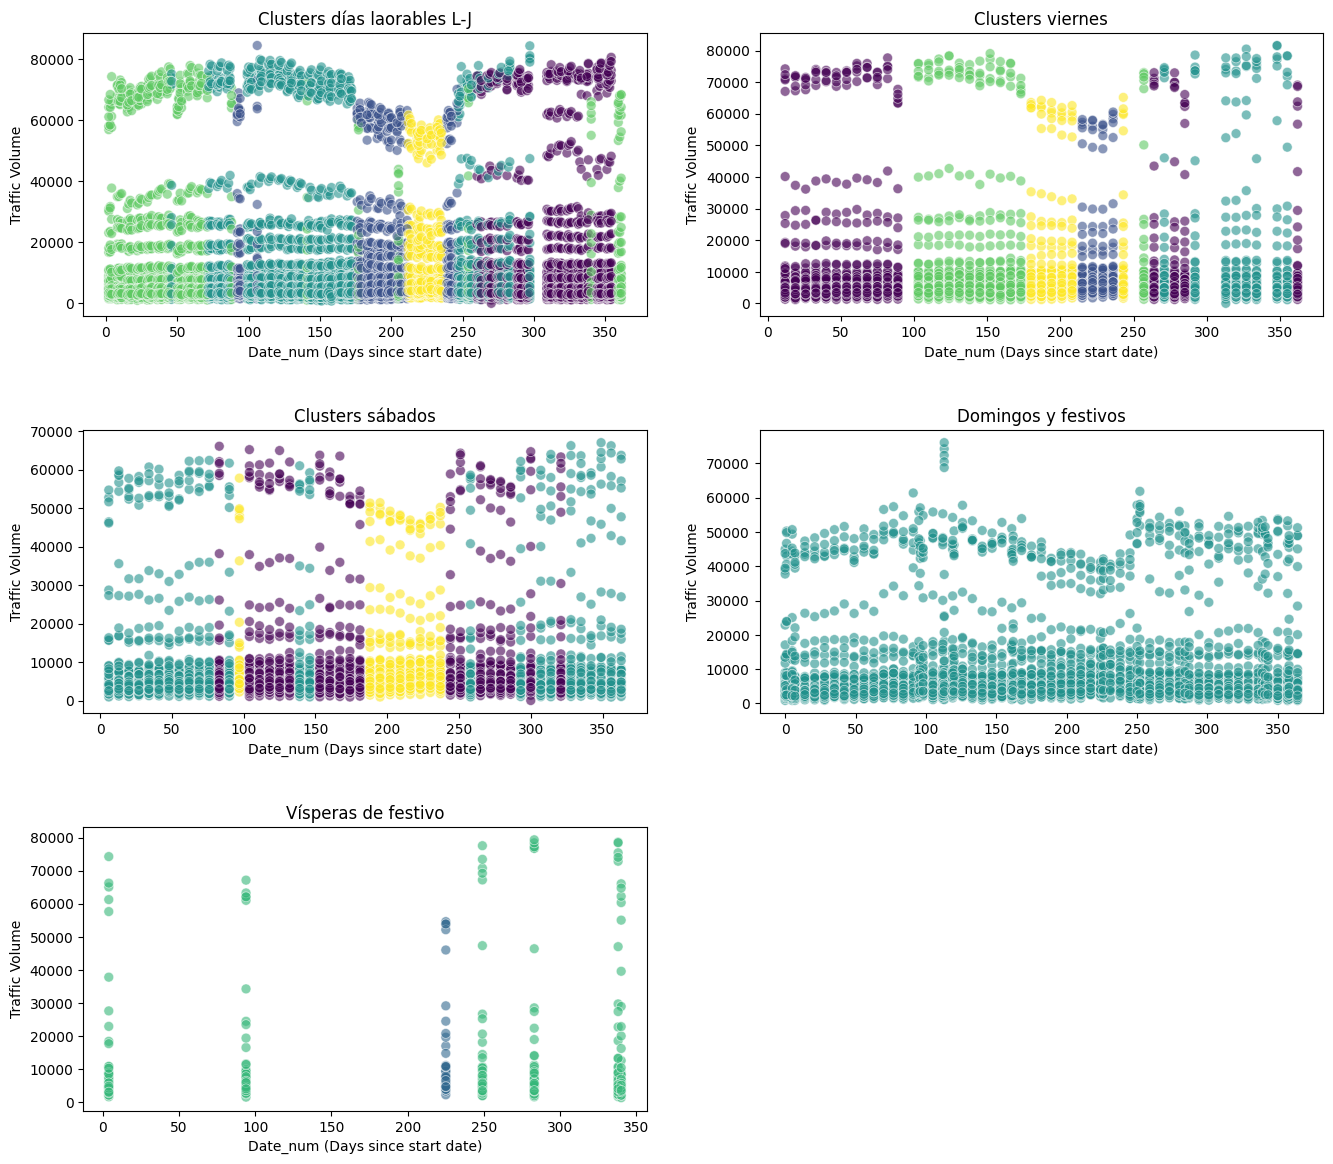

In [9]:
# Scatter plot with date_num on X-axis and traffic counts on Y-axis
import seaborn as sns
import matplotlib.pyplot as plt

# Number of clusters (replace with optimal K determined from previous analysis)
optimal_k_mon2thu = 5  # Replace with the actual optimal number
optimal_k_friday = 5  # Replace with the actual optimal number
optimal_k_saturday = 3  # Replace with the actual optimal number
optimal_k_sunday = 1  # Replace with the actual optimal number
optimal_k_eves = 2

# Apply KMeans clustering with optimal K
kmeans_mon2thu = KMeans(n_clusters=optimal_k_mon2thu, random_state=42, n_init=10)
labels_mon2thu = kmeans_mon2thu.fit_predict(X_mon2thu_scaled)

kmeans_friday = KMeans(n_clusters=optimal_k_friday, random_state=42, n_init=10)
labels_friday = kmeans_friday.fit_predict(X_friday_scaled)

kmeans_saturday = KMeans(n_clusters=optimal_k_saturday, random_state=42, n_init=10)
labels_saturday = kmeans_saturday.fit_predict(X_saturday_scaled)

kmeans_sunday = KMeans(n_clusters=optimal_k_sunday, random_state=42, n_init=10)
labels_sunday = kmeans_sunday.fit_predict(X_sunday_scaled)

kmeans_eves = KMeans(n_clusters=optimal_k_eves, random_state=42)
labels_eves = kmeans_eves.fit_predict(X_eves_scaled)

# Add cluster labels to the pivoted data for weekday and weekend data
pivot_mon2thu['Cluster'] = labels_mon2thu
pivot_friday['Cluster'] = labels_friday
pivot_saturday['Cluster'] = labels_saturday
pivot_sunday['Cluster'] = labels_sunday
pivot_eves['Cluster'] = labels_eves

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.subplots_adjust(hspace=0.4)  # Adjust vertical spacing between plots

# Plot for monday to thursday data
for origin in pivot_mon2thu.columns[:-1]:  # Exclude the 'Cluster' column
    sns.scatterplot(x=pivot_mon2thu.index, y=pivot_mon2thu[origin], hue=pivot_mon2thu['Cluster'],
                    palette="viridis", legend=False, s=50, alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title("Clusters días laorables L-J")
axes[0, 0].set_xlabel("Date_num (Days since start date)")
axes[0, 0].set_ylabel("Traffic Volume")

# Plot for friday data
for origin in pivot_friday.columns[:-1]:  # Exclude the 'Cluster' column
    sns.scatterplot(x=pivot_friday.index, y=pivot_friday[origin], hue=pivot_friday['Cluster'],
                    palette="viridis", legend=False, s=50, alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title("Clusters viernes")
axes[0, 1].set_xlabel("Date_num (Days since start date)")
axes[0, 1].set_ylabel("Traffic Volume")


# Plot for Saturday data
for origin in pivot_saturday.columns[:-1]:  # Exclude the 'Cluster' column
    sns.scatterplot(x=pivot_saturday.index, y=pivot_saturday[origin], hue=pivot_saturday['Cluster'],
                    palette="viridis", legend=False, s=50, alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title("Clusters sábados")
axes[1, 0].set_xlabel("Date_num (Days since start date)")
axes[1, 0].set_ylabel("Traffic Volume")

# Plot for Sunday data
for origin in pivot_sunday.columns[:-1]:  # Exclude the 'Cluster' column
    sns.scatterplot(x=pivot_sunday.index, y=pivot_sunday[origin], hue=pivot_sunday['Cluster'],
                    palette="viridis", legend=False, s=50, alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title("Domingos y festivos")
axes[1, 1].set_xlabel("Date_num (Days since start date)")
axes[1, 1].set_ylabel("Traffic Volume")

# Plot for BH eves data
for origin in pivot_eves.columns[:-1]:  # Exclude the 'Cluster' column
    sns.scatterplot(x=pivot_eves.index, y=pivot_eves[origin], hue=pivot_eves['Cluster'],
                    palette="viridis", legend=False, s=50, alpha=0.6, ax=axes[2, 0])
axes[2, 0].set_title("Vísperas de festivo")
axes[2, 0].set_xlabel("Date_num (Days since start date)")
axes[2, 0].set_ylabel("Traffic Volume")

axes[2, 1].axis('off')
plt.show()


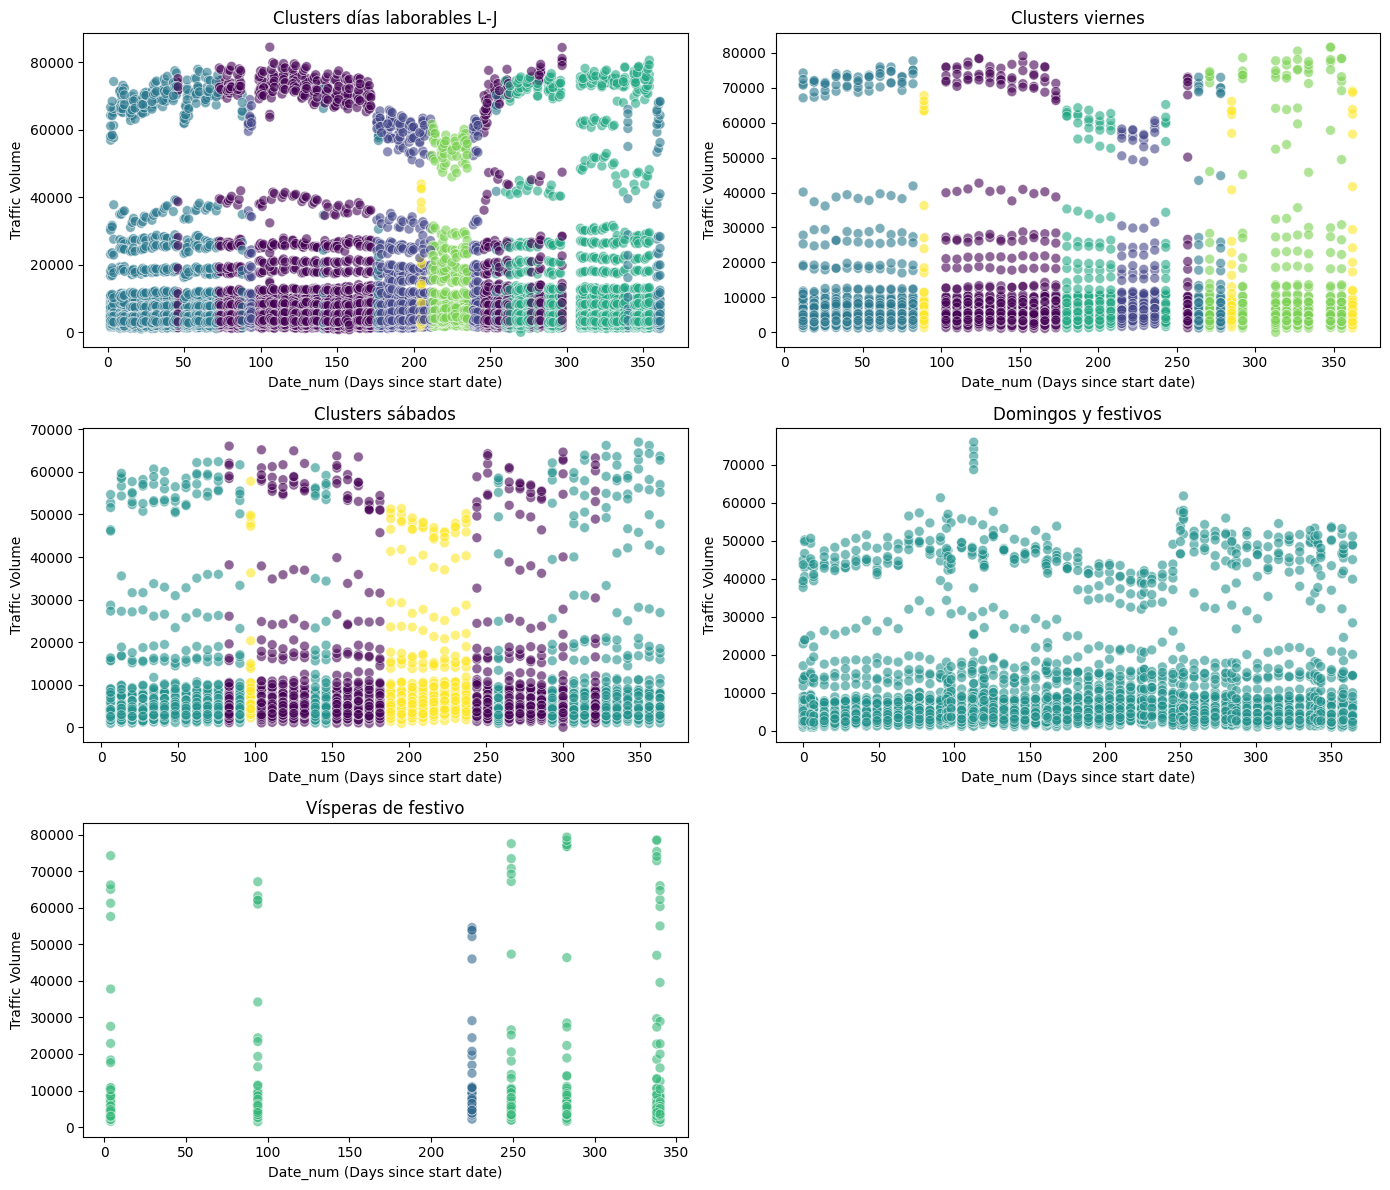

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define data and titles
data_pivots = [pivot_mon2thu, pivot_friday, pivot_saturday, pivot_sunday, pivot_eves]
titles = [
    "Clusters días laborables L-J",
    "Clusters viernes",
    "Clusters sábados",
    "Domingos y festivos",
    "Vísperas de festivo"
]

# Create a single figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()  # Flatten axes for easier indexing

# Loop through datasets and plot
for i, (pivot, title) in enumerate(zip(data_pivots, titles)):
    if i >= len(axes) - 1:  # Skip the last unused subplot
        break
    for origin in pivot.columns[:-1]:  # Exclude 'Cluster' column
        sns.scatterplot(
            x=pivot.index,
            y=pivot[origin],
            hue=pivot['Cluster'],
            palette="viridis",
            legend=False,
            s=50,
            alpha=0.6,
            ax=axes[i]
        )
    axes[i].set_title(title)
    axes[i].set_xlabel("Date_num (Days since start date)")
    axes[i].set_ylabel("Traffic Volume")

# Turn off the last unused axis
axes[-1].axis('off')

# Adjust layout and show plot
fig.tight_layout()
plt.show()


### Concatenate and export to csv

In [6]:
# Add a new column to each DataFrame to identify the file origin
pivot_mon2thu['day_type'] = 'mon2thu'
pivot_friday['day_type'] = 'friday'
pivot_saturday['day_type'] = 'saturday'
pivot_sunday['day_type'] = 'sunday'

# Concatenate all DataFrames
combined_df = pd.concat([pivot_mon2thu, pivot_friday, pivot_saturday, pivot_sunday])
combined_df.sort_values(['day_type', 'date_num'], inplace=True)
# Export the combined DataFrame to a single CSV file
combined_df.to_csv('D:/Ctym/p/p174_GemeloDigital_Leon/5_Trabajo/dev/combined_clusters.csv', index=True)


In [7]:
data_mon2thu.loc[:, 'day_type'] = 'mon2thu'
data_friday.loc[:, 'day_type'] = 'friday'
data_saturday.loc[:, 'day_type'] = 'saturday'
data_sunday.loc[:, 'day_type'] = 'sunday'
data_eves.loc[:, 'day_type'] = 'BH-eves'

combined_df = pd.concat([data_mon2thu, data_friday, data_saturday, data_sunday, data_eves])
combined_df = combined_df[['date_str', 'date_num', 'day_type']]
combined_df.drop_duplicates(inplace=True)
combined_df.sort_values(['day_type', 'date_num'], inplace=True)
combined_df.to_csv('D:/Ctym/p/p174_GemeloDigital_Leon/5_Trabajo/dev/dates.csv', index=False)


C:\Users\Jose\AppData\Local\Temp\ipykernel_4980\2231996409.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_mon2thu.loc[:, 'day_type'] = 'mon2thu'
C:\Users\Jose\AppData\Local\Temp\ipykernel_4980\2231996409.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_friday.loc[:, 'day_type'] = 'friday'
C:\Users\Jose\AppData\Local\Temp\ipykernel_4980\2231996409.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value